In [1]:
from pathlib import Path 
import os
os.environ['MUJOCO_GL'] = 'egl'
os.environ['MKL_SERVICE_FORCE_INTEL'] = '1'
from tqdm import tqdm
from IPython.display import Video

import torch
import numpy as np

import sys
sys.path.append("/srv/sferraro/choreographer/")

import envs

import matplotlib.pyplot as plt
import matplotlib.animation as animation

/home/elephant/.local/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/elephant/miniconda3/envs/urlb/lib/python3.8/site-packages/robosuite-1.4.0-py3.8.egg/robosuite/__init__.py:7: DeprecationWarning: The 'warn' method is deprecated, use 'warning' instead
  ROBOSUITE_DEFAULT_LOGGER.warn("No private macro file found!")
[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /home/elephant/miniconda3/envs/urlb/lib/python3.8/site-packages/robosuite-1.4.0-py3.8.egg/robosuite/scripts/setup_macros.py (__init__.py:9)


In [2]:
# Import agent model (WM + Actor Critic)
agent_path = Path(f'/srv/sferraro/choreographer/eval/models/right_0025/last_snapshot.pt')

def load_agent(agent_path):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    with agent_path.open('rb') as f:
        obj = torch.load(f, map_location=torch.device(device))
        agent = obj['agent']    
        step = obj['_global_step']
        agent.device = device
        agent.wm.device = device
        agent.wm.rssm.device = device
        agent.wm.rssm._cell.device = device
    return agent, step

agent, global_step = load_agent(agent_path)

In [3]:
from hydra import compose, initialize
from omegaconf import OmegaConf

initialize(config_path="../exp_local/2023.04.04/084715_dreamer/.hydra", job_name="config")
cfg = compose(config_name="config")

In [4]:
# Agent parametrization
obs_type = agent.cfg.obs_type
action_repeat = agent.cfg.action_repeat
snapshot_ts = global_step * action_repeat

agent.reward_free = True

agent.use_selector = False
agent.detached_exploration = True

seed = agent.cfg.seed

task = "panda_CustomLift"
domain = task.split("_")[0]

cfg.env.objects.minsize = 0.025

# Env creation
eval_env = envs.make(task, obs_type, frame_stack=1, 
                    action_repeat=action_repeat, seed=seed, env_config=cfg.env)

/home/elephant/miniconda3/envs/urlb/lib/python3.8/site-packages/gym/spaces/box.py:84: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


  0%|          | 0/1 [00:00<?, ?it/s]

Cube position: [-0.02785633 -0.01483838  0.8564651 ]
Predicted position: [-0.00308557  0.04488386  0.85499775]
Pixels in view: 12


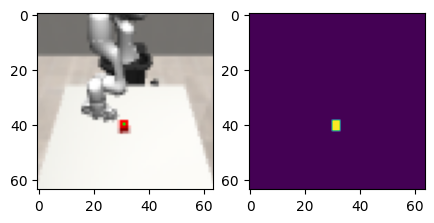

Cube position: [-0.02628476 -0.01480634  0.85839444]
Predicted position: [-1.0116935e-02  7.9034455e-04  8.6073172e-01]
Pixels in view: 12


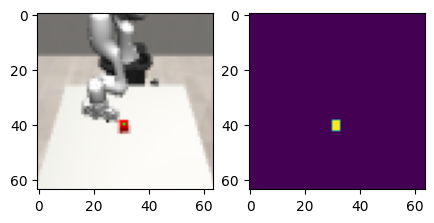

Cube position: [-0.02593492 -0.01479921  0.8588239 ]
Predicted position: [-0.0104054   0.0060859   0.86593384]
Pixels in view: 12


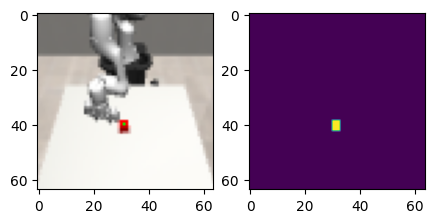

Cube position: [-0.02576703 -0.01479579  0.85903   ]
Predicted position: [-0.01393713  0.00436064  0.86426723]
Pixels in view: 16


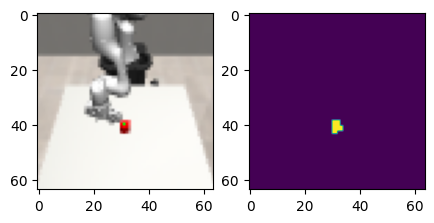

Cube position: [-0.00733401 -0.01463063  0.85861635]
Predicted position: [-1.1327619e-02  4.8078038e-04  8.6584526e-01]
Pixels in view: 19


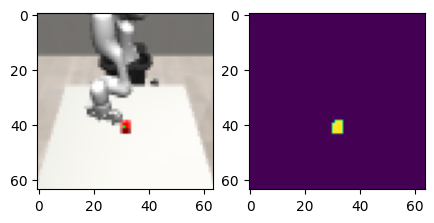

Cube position: [-0.00719473 -0.01462775  0.8587919 ]
Predicted position: [-0.01382341  0.0012926   0.86667156]
Pixels in view: 18


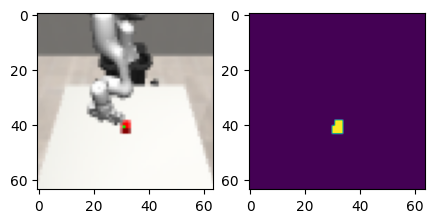

Cube position: [-0.00715885 -0.014627    0.85883707]
Predicted position: [-1.0574207e-02  5.2883849e-04  8.6603069e-01]
Pixels in view: 17


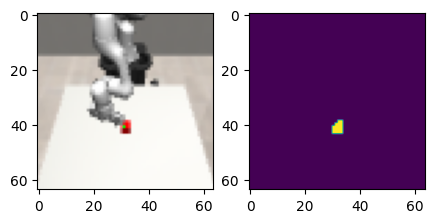

Cube position: [-0.00714542 -0.01462672  0.858854  ]
Predicted position: [-0.0168288  -0.00301744  0.8669594 ]
Pixels in view: 15


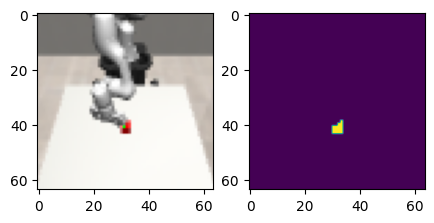

Cube position: [-0.00690751  0.          0.8591538 ]
Predicted position: [-0.00714942 -0.00533301  0.86446667]
Pixels in view: 11


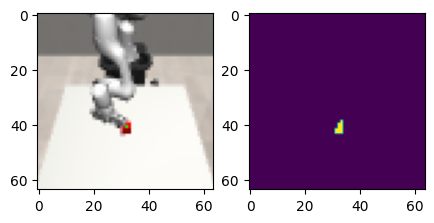

Cube position: [-0.00467164  0.          0.8619715 ]
Predicted position: [-0.00446408 -0.00313848  0.8656891 ]
Pixels in view: 10


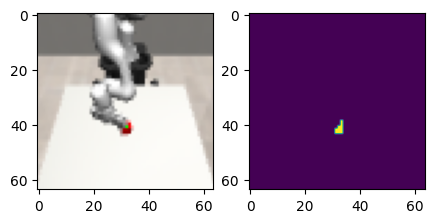

Cube position: [0.01975736 0.         0.89275694]
Predicted position: [-0.00751482 -0.02022587  0.86454844]
Pixels in view: 10


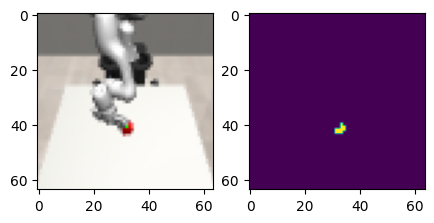

Cube position: [0.00777092 0.01453042 0.85443264]
Predicted position: [-0.00472959 -0.00769744  0.865461  ]
Pixels in view: 10


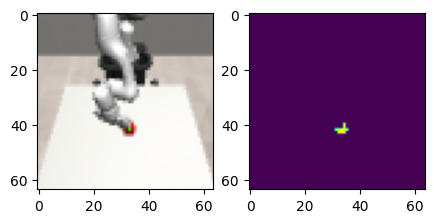

Cube position: [0.01566423 0.02872948 0.8646446 ]
Predicted position: [-1.3104081e-04  1.0537375e-03  8.6893666e-01]
Pixels in view: 13


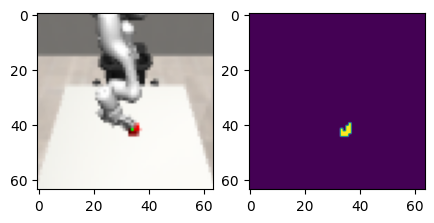

Cube position: [0.01383761 0.05761232 0.86228144]
Predicted position: [-7.0428103e-04  8.7623391e-03  8.6534584e-01]
Pixels in view: 12


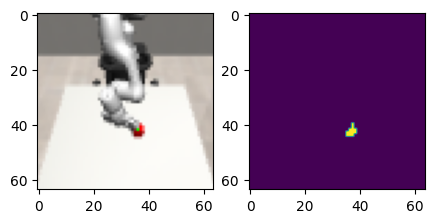

Cube position: [0.01323658 0.08649419 0.86150384]
Predicted position: [0.01450196 0.02882759 0.86750907]
Pixels in view: 9


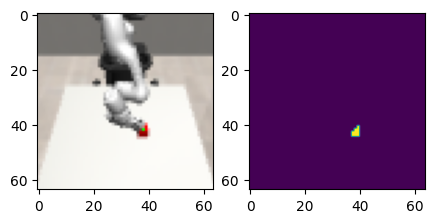

Cube position: [0.02518944 0.10064541 0.853652  ]
Predicted position: [0.02037837 0.03892127 0.8658201 ]
Pixels in view: 11


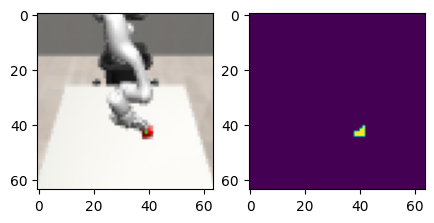

Cube position: [0.02545884 0.10060522 0.85400987]
Predicted position: [0.02022967 0.05750278 0.86275977]
Pixels in view: 9


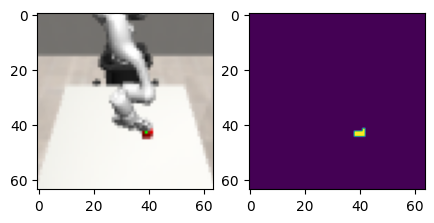

Cube position: [0.02545884 0.10060522 0.85400987]
Predicted position: [0.02478324 0.06588151 0.862873  ]
Pixels in view: 7


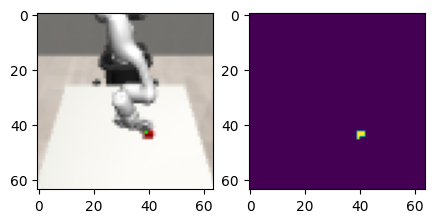

Cube position: [0.03191969 0.11561564 0.8388033 ]
Predicted position: [0.02115754 0.04997411 0.8616742 ]
Pixels in view: 10


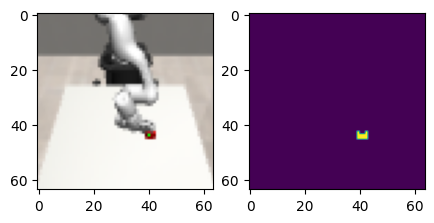

Cube position: [0.03575274 0.12932134 0.8440312 ]
Predicted position: [0.02232389 0.04936858 0.8609153 ]
Pixels in view: 9


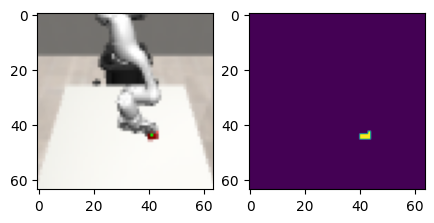

Cube position: [0.03575274 0.12932134 0.8440312 ]
Predicted position: [0.0288038  0.05916704 0.86352676]
Pixels in view: 8


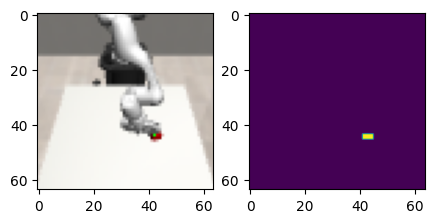

Cube position: [0.03575274 0.12932134 0.8440312 ]
Predicted position: [0.03135544 0.05903441 0.8650811 ]
Pixels in view: 8


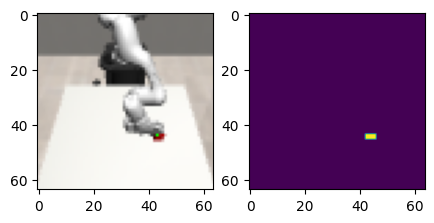

Cube position: [0.03575274 0.12932134 0.8440312 ]
Predicted position: [0.02927085 0.0594726  0.86694527]
Pixels in view: 6


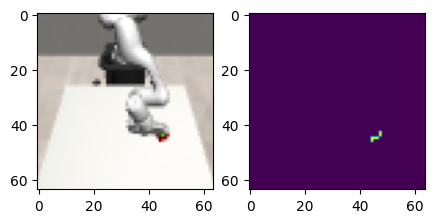

Cube position: [0.03575274 0.12932134 0.8440312 ]
Predicted position: [0.02665183 0.05172909 0.86844945]
Pixels in view: 3


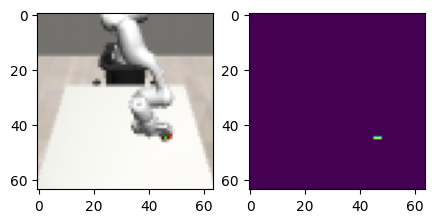

Cube position: [0.03575274 0.12932134 0.8440312 ]
Predicted position: [0.02519782 0.05392502 0.86698365]
Pixels in view: 2


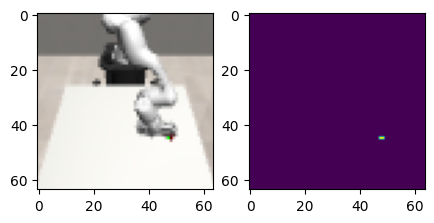

Cube position: [0.03575274 0.12932134 0.8440312 ]
Predicted position: [0.01577393 0.04870133 0.8696739 ]
Pixels in view: 3


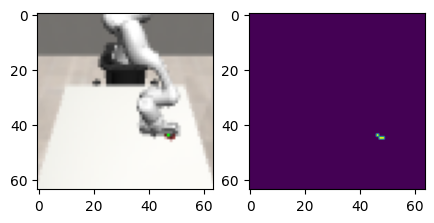

Cube position: [0.03575274 0.12932134 0.8440312 ]
Predicted position: [0.01207658 0.03185856 0.8672658 ]
Pixels in view: 5


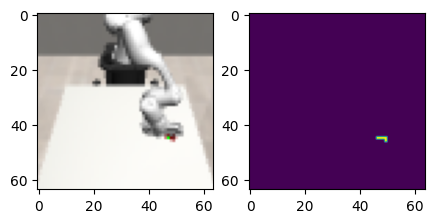

Cube position: [0.03575274 0.12932134 0.8440312 ]
Predicted position: [0.00968286 0.02411654 0.8684145 ]
Pixels in view: 6


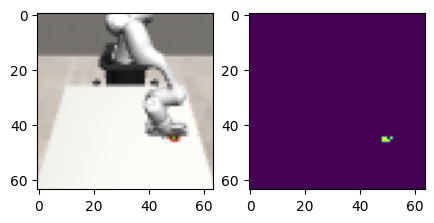

Cube position: [0.03575274 0.12932134 0.8440312 ]
Predicted position: [0.00922655 0.0194826  0.868552  ]
Pixels in view: 8


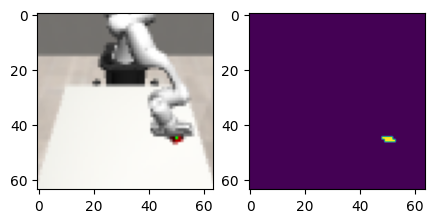

Cube position: [0.03575274 0.12932134 0.8440312 ]
Predicted position: [0.0190454 0.0577573 0.8665818]
Pixels in view: 6


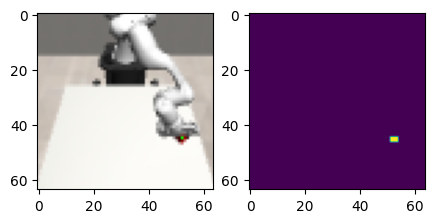

Cube position: [0.03575274 0.12932134 0.8440312 ]
Predicted position: [0.04250908 0.08550227 0.869429  ]
Pixels in view: 2


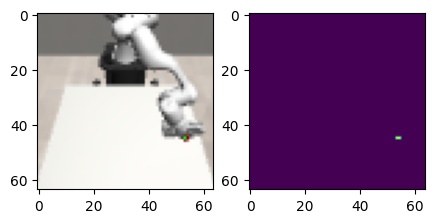

Cube position: [0.03575274 0.12932134 0.8440312 ]
Predicted position: [0.03734855 0.09290585 0.8715227 ]
Pixels in view: 2


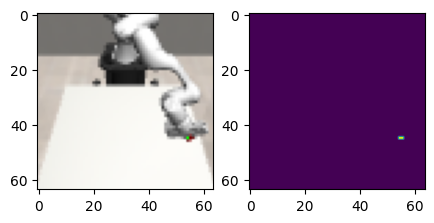

Cube position: [0.03575274 0.12932134 0.8440312 ]
Predicted position: [0.03206465 0.07699958 0.8676927 ]
Pixels in view: 4


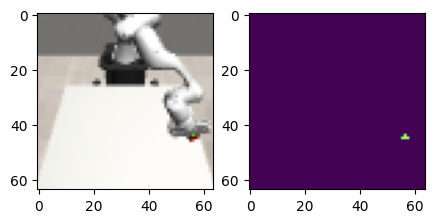

Cube position: [0.03575274 0.12932134 0.8440312 ]
Predicted position: [0.02466618 0.08583716 0.8656714 ]
Pixels in view: 5


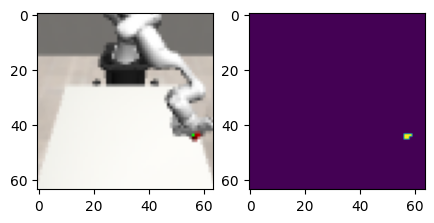

Cube position: [0.03575274 0.12932134 0.8440312 ]
Predicted position: [0.03121283 0.13746873 0.86346865]
Pixels in view: 8


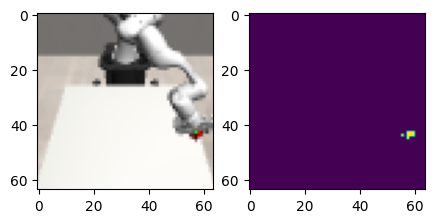

Cube position: [0.03575274 0.12932134 0.8440312 ]
Predicted position: [0.03222797 0.1836876  0.8579813 ]
Pixels in view: 6


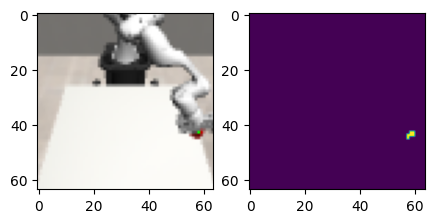

Cube position: [0.03024232 0.37102664 0.8603637 ]
Predicted position: [0.03040937 0.17495567 0.8609901 ]
Pixels in view: 9


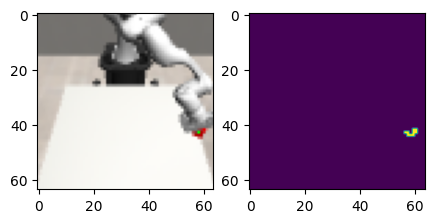

Cube position: [0.0225444  0.3839486  0.87354577]
Predicted position: [0.03470252 0.22132055 0.8513754 ]
Pixels in view: 10


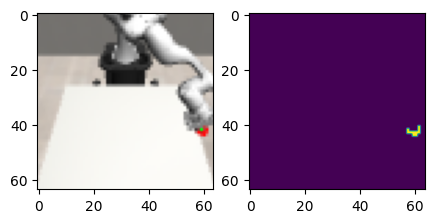

Cube position: [0.00764867 0.39239076 0.8542745 ]
Predicted position: [0.02791972 0.27133992 0.8431615 ]
Pixels in view: 16


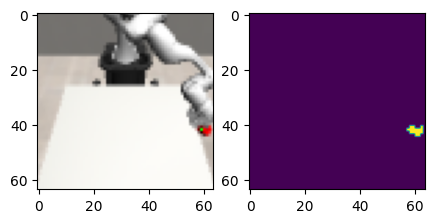

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [0.0164395 0.2851266 0.8337769]
Pixels in view: 15


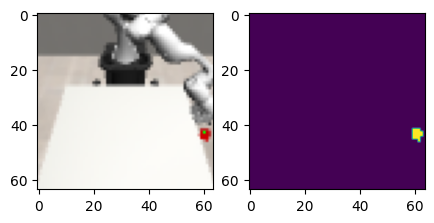

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [0.00647882 0.3111101  0.82678384]
Pixels in view: 6


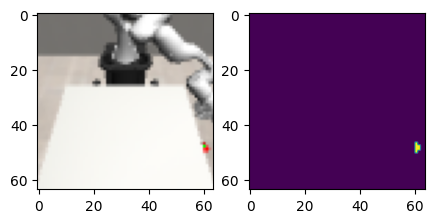

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [0.00686464 0.33677608 0.8074994 ]
Pixels in view: 0


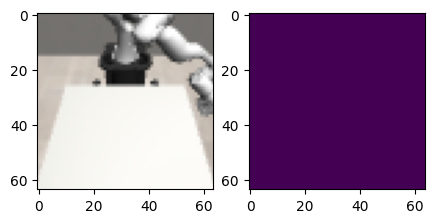

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.01533749  0.35305816  0.7984796 ]
Pixels in view: 0


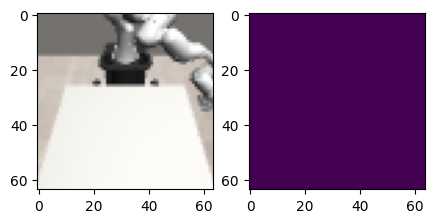

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.0281083   0.34366283  0.80241656]
Pixels in view: 0


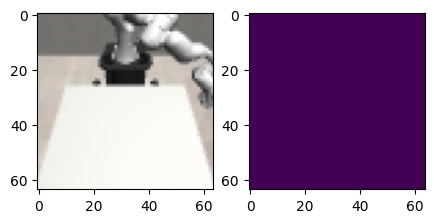

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.02154437  0.33527502  0.8032914 ]
Pixels in view: 0


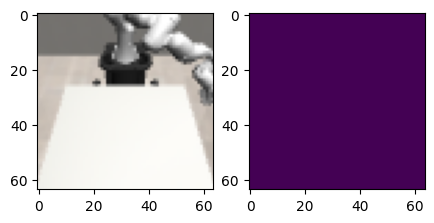

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.0203149   0.33978066  0.79401594]
Pixels in view: 0


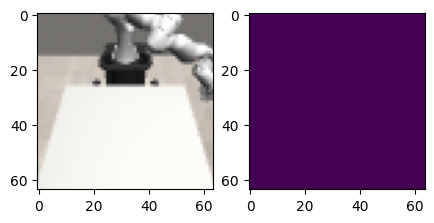

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.01307415  0.35116634  0.7907173 ]
Pixels in view: 0


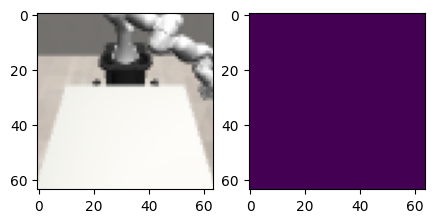

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.00500287  0.36227837  0.79335344]
Pixels in view: 0


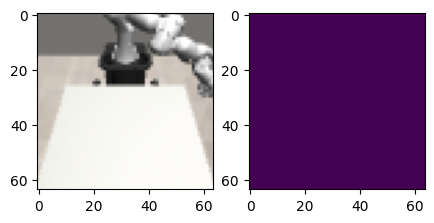

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-7.2829425e-05  3.3203626e-01  8.0250895e-01]
Pixels in view: 0


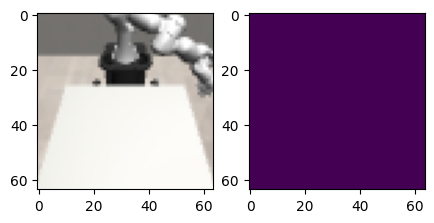

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.01236209  0.32936195  0.7976321 ]
Pixels in view: 0


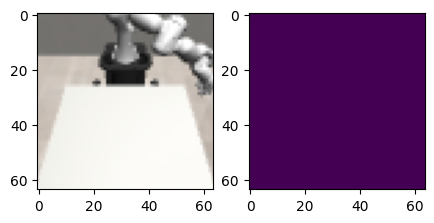

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [0.00761263 0.33739504 0.79911685]
Pixels in view: 0


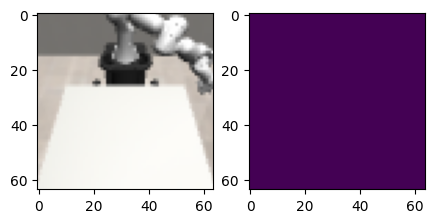

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [0.00679817 0.3380577  0.7965058 ]
Pixels in view: 0


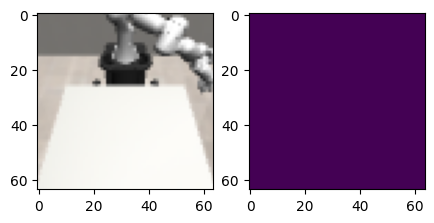

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [0.01625559 0.34077707 0.80319357]
Pixels in view: 0


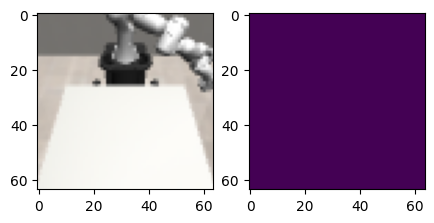

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [0.01180413 0.34682703 0.8024179 ]
Pixels in view: 0


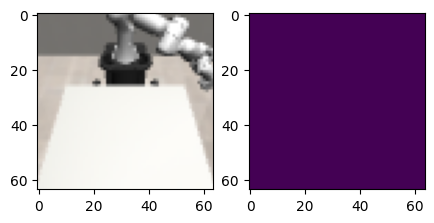

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [0.01602818 0.33864653 0.8037828 ]
Pixels in view: 0


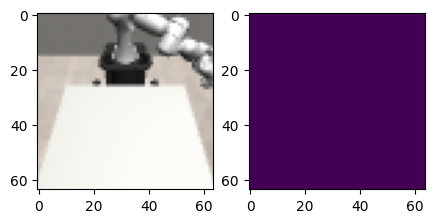

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [0.01418178 0.34825647 0.80234504]
Pixels in view: 0


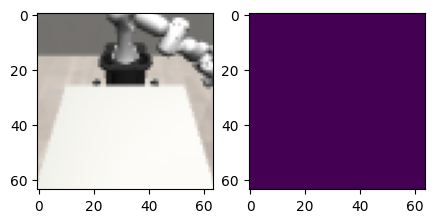

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [0.01562207 0.34083965 0.8060937 ]
Pixels in view: 0


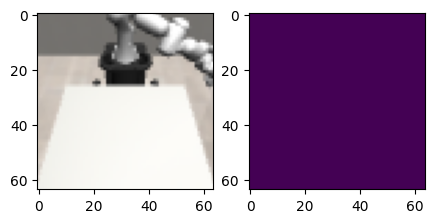

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [0.01444237 0.3534697  0.80252564]
Pixels in view: 0


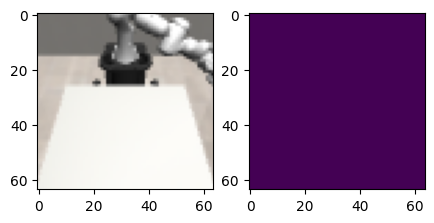

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [0.02564153 0.34881625 0.80553687]
Pixels in view: 0


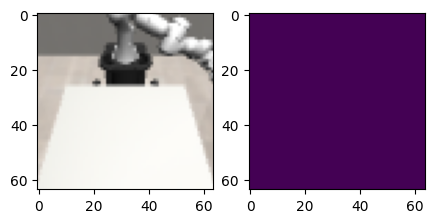

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [0.01226531 0.3443984  0.80421627]
Pixels in view: 0


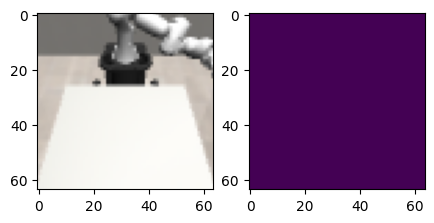

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [0.01671256 0.36503598 0.8028158 ]
Pixels in view: 0


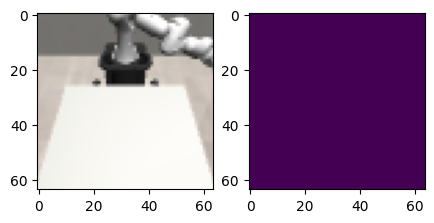

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [0.00910551 0.3504834  0.8024239 ]
Pixels in view: 0


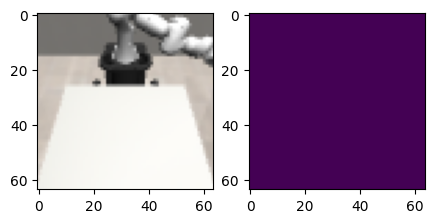

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [0.00530013 0.3641644  0.80640674]
Pixels in view: 0


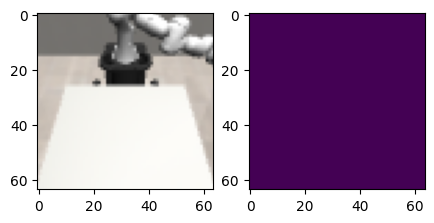

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [0.011973   0.34814197 0.804164  ]
Pixels in view: 0


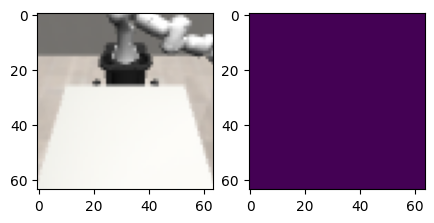

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [0.01298645 0.35332665 0.8083818 ]
Pixels in view: 0


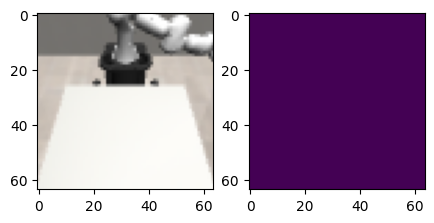

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [0.01095653 0.34008288 0.8046819 ]
Pixels in view: 0


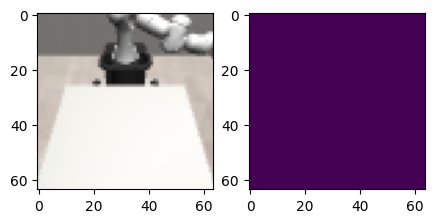

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [0.0128806 0.3365381 0.807073 ]
Pixels in view: 0


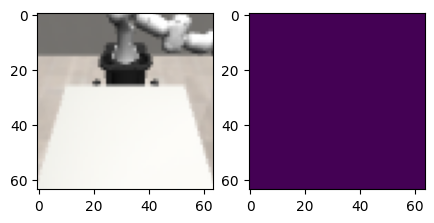

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [0.01046514 0.3495597  0.80565655]
Pixels in view: 0


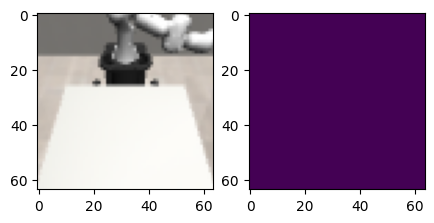

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [0.00221235 0.35234016 0.80276746]
Pixels in view: 0


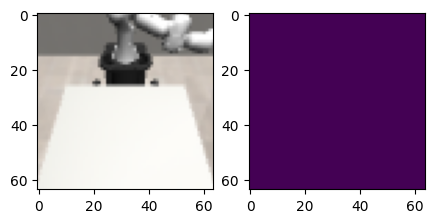

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [0.00935483 0.3467827  0.80319095]
Pixels in view: 0


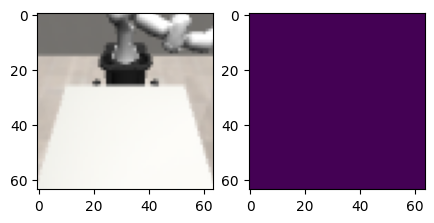

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [0.01442932 0.34219435 0.8056264 ]
Pixels in view: 0


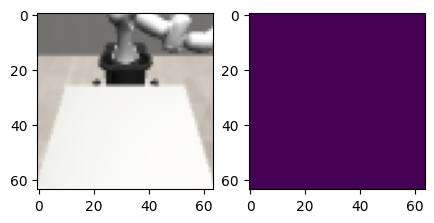

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [0.00734295 0.34096584 0.803931  ]
Pixels in view: 0


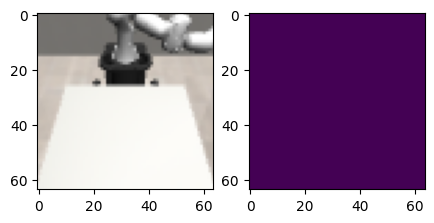

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [0.01133745 0.345499   0.8019554 ]
Pixels in view: 0


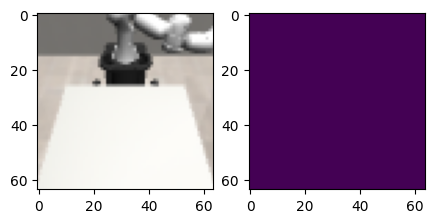

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [0.00860005 0.3449606  0.8078743 ]
Pixels in view: 0


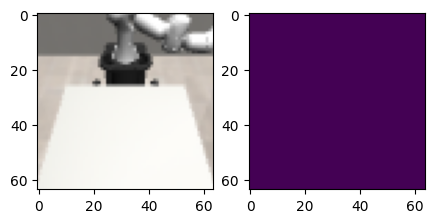

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [0.00524018 0.33526972 0.80574036]
Pixels in view: 0


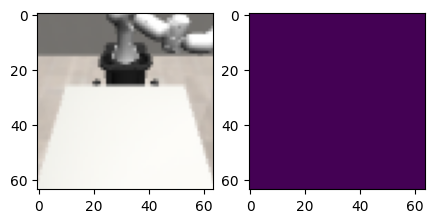

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [0.00786214 0.3408785  0.8026423 ]
Pixels in view: 0


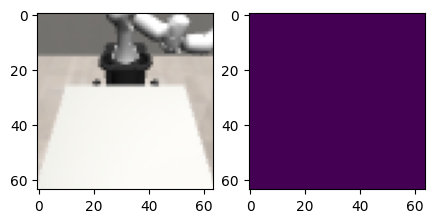

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [0.00398543 0.33999905 0.8051308 ]
Pixels in view: 0


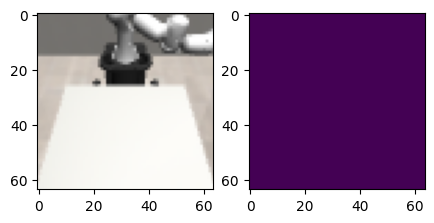

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.00718027  0.34388334  0.80157316]
Pixels in view: 0


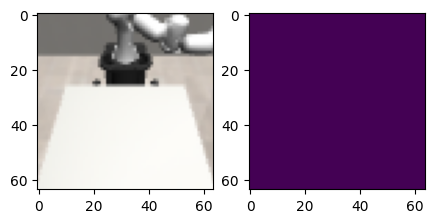

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.00883504  0.34759006  0.79726666]
Pixels in view: 0


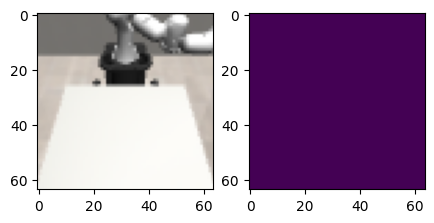

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.01634973  0.35170546  0.7944382 ]
Pixels in view: 0


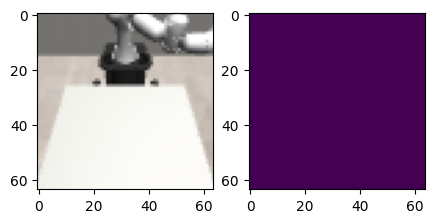

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.01111073  0.33944756  0.80138475]
Pixels in view: 0


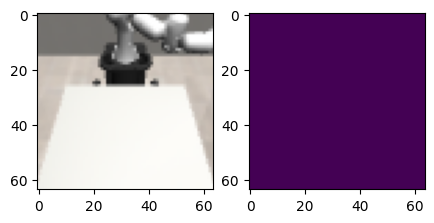

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.01892288  0.34268317  0.8030679 ]
Pixels in view: 0


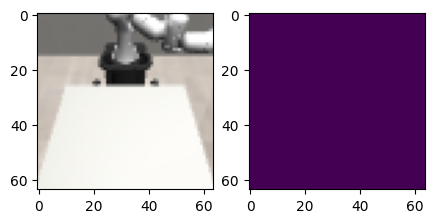

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.00992122  0.34374785  0.80358356]
Pixels in view: 0


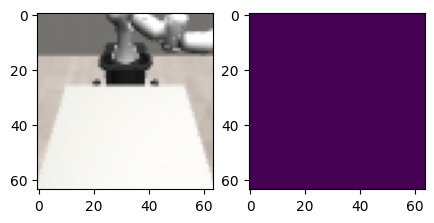

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.01308367  0.33554044  0.8029338 ]
Pixels in view: 0


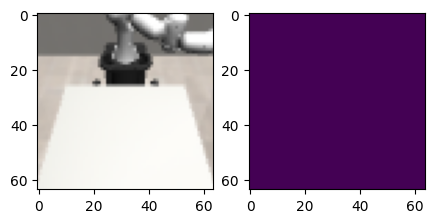

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.01360082  0.33978888  0.8065634 ]
Pixels in view: 0


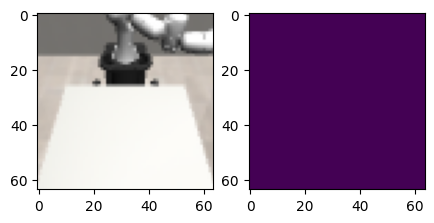

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.01590557  0.32795036  0.8035141 ]
Pixels in view: 0


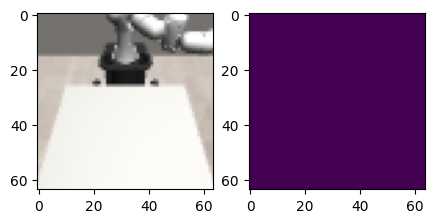

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.01475772  0.3448499   0.8030069 ]
Pixels in view: 0


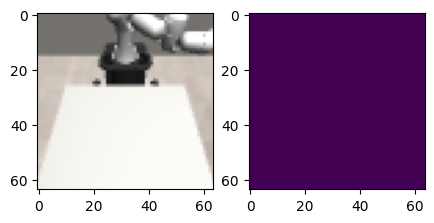

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.01755793  0.34098634  0.80006576]
Pixels in view: 0


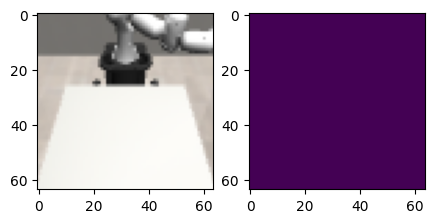

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.01587641  0.3361536   0.80674356]
Pixels in view: 0


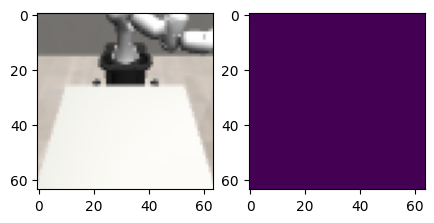

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.02323592  0.34095615  0.8032273 ]
Pixels in view: 0


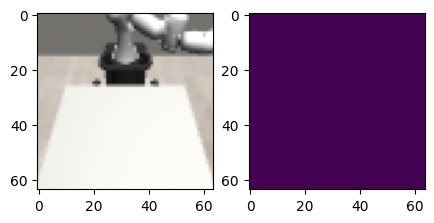

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.02456571  0.3464943   0.79667765]
Pixels in view: 0


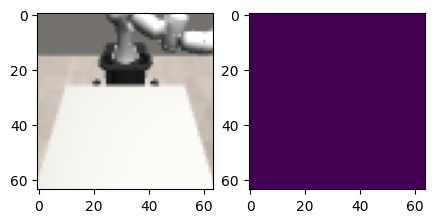

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.02347067  0.33583307  0.8054795 ]
Pixels in view: 0


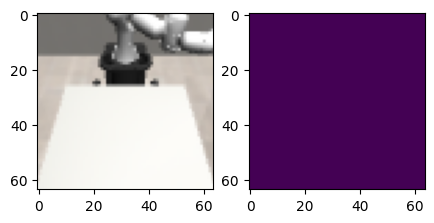

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.0299851   0.34215662  0.8011368 ]
Pixels in view: 0


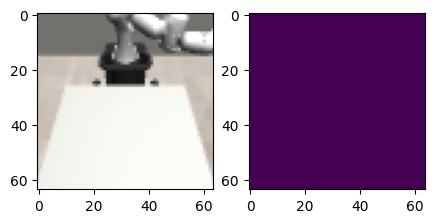

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.01931329  0.32585433  0.80608976]
Pixels in view: 0


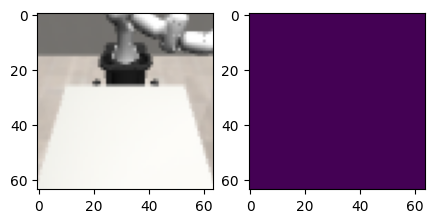

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.02794218  0.34602845  0.803421  ]
Pixels in view: 0


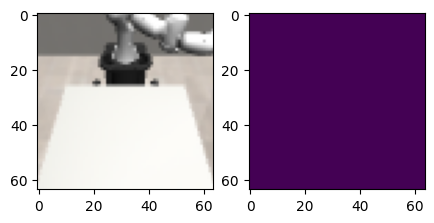

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.01304153  0.33604157  0.80470854]
Pixels in view: 0


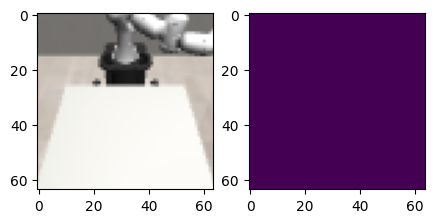

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.01697634  0.33433583  0.8048824 ]
Pixels in view: 0


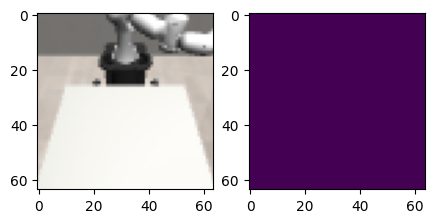

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.03265405  0.34918982  0.8022584 ]
Pixels in view: 0


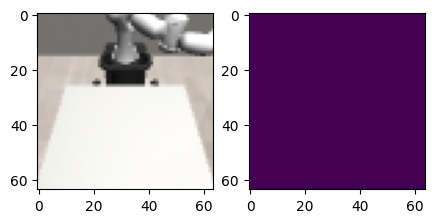

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.0128057  0.3431708  0.8028192]
Pixels in view: 0


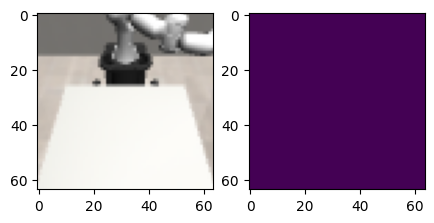

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.0212261   0.3394432   0.79909074]
Pixels in view: 0


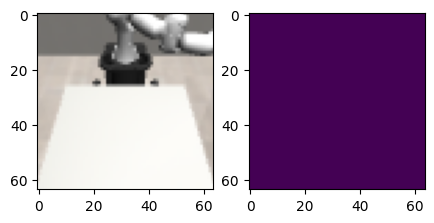

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.02013986  0.33426827  0.8044592 ]
Pixels in view: 0


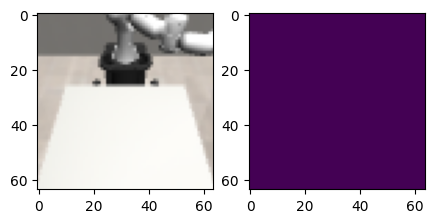

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.02191328  0.34253     0.80078816]
Pixels in view: 0


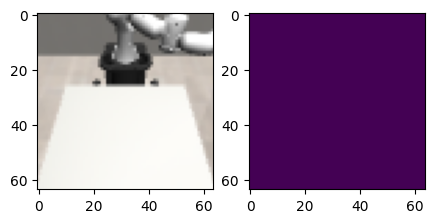

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.0214512   0.34545997  0.80643356]
Pixels in view: 0


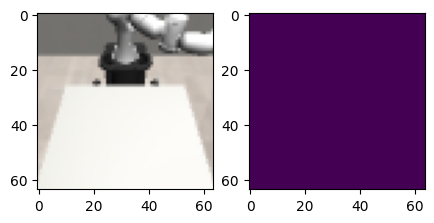

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.01398785  0.3422487   0.8063582 ]
Pixels in view: 0


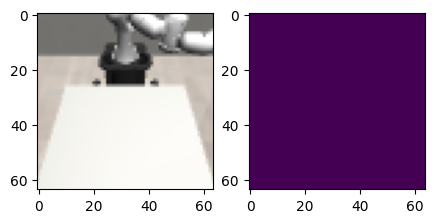

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.02416509  0.34629592  0.8037516 ]
Pixels in view: 0


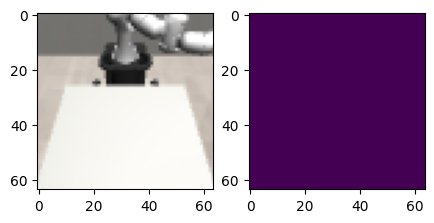

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.02357316  0.32760918  0.80648375]
Pixels in view: 0


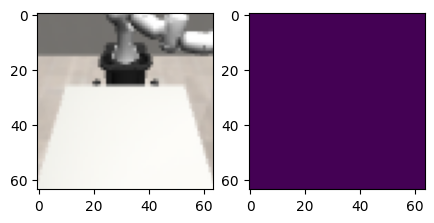

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.02782728  0.33117956  0.8075343 ]
Pixels in view: 0


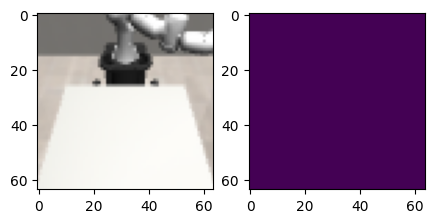

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.02799084  0.34330946  0.8007121 ]
Pixels in view: 0


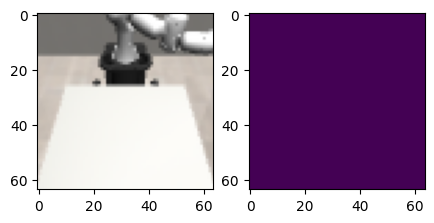

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.03001493  0.33615083  0.80524755]
Pixels in view: 0


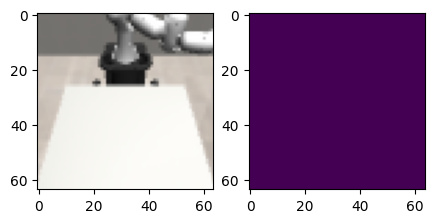

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.01774823  0.34139687  0.8075033 ]
Pixels in view: 0


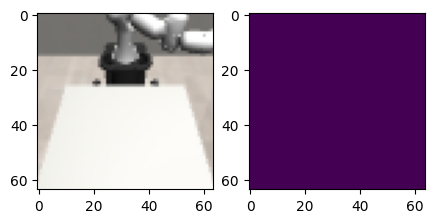

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.0237685   0.33215618  0.8080426 ]
Pixels in view: 0


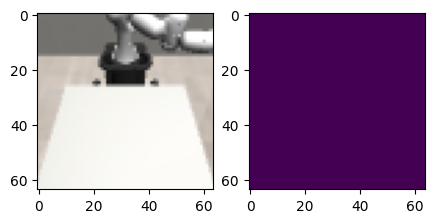

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.02255704  0.33346915  0.80700374]
Pixels in view: 0


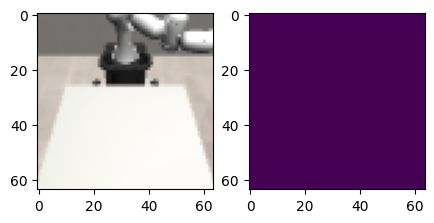

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.02232044  0.32358086  0.8084344 ]
Pixels in view: 0


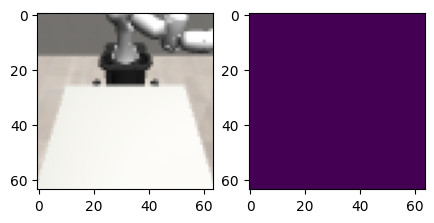

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.02527519  0.3309023   0.8083899 ]
Pixels in view: 0


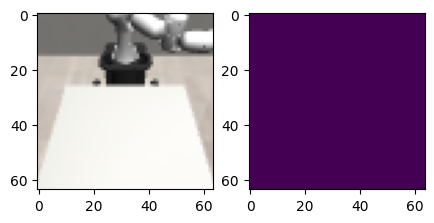

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.02025867  0.32279846  0.80827415]
Pixels in view: 0


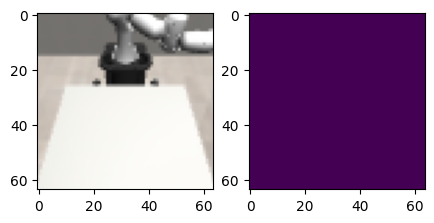

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.01853184  0.33079806  0.8086883 ]
Pixels in view: 0


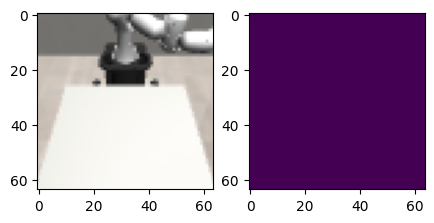

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.02232471  0.3336454   0.8072765 ]
Pixels in view: 0


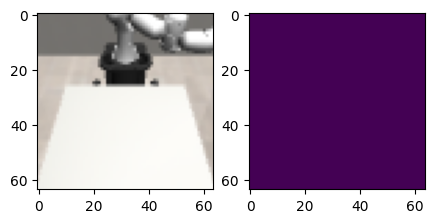

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.01967532  0.32836202  0.8080128 ]
Pixels in view: 0


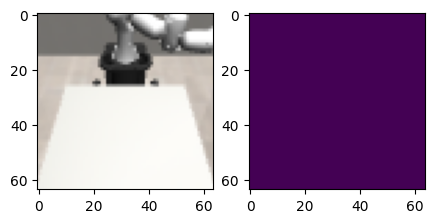

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.02037215  0.3186407   0.81084645]
Pixels in view: 0


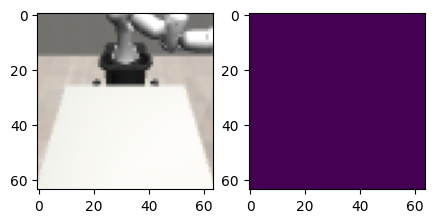

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.02321526  0.31803277  0.8116565 ]
Pixels in view: 0


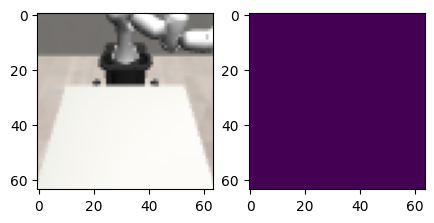

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.03436394  0.32353032  0.8121799 ]
Pixels in view: 0


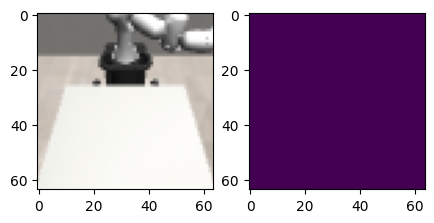

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.02265074  0.3113951   0.81233203]
Pixels in view: 0


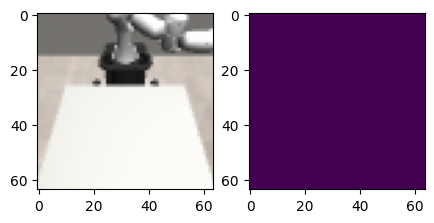

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.02704406  0.31667936  0.8098904 ]
Pixels in view: 0


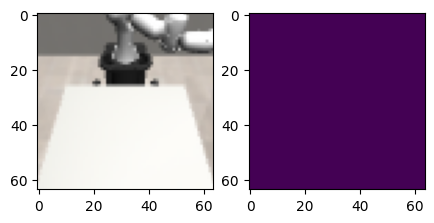

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.03905427  0.31886125  0.8080481 ]
Pixels in view: 0


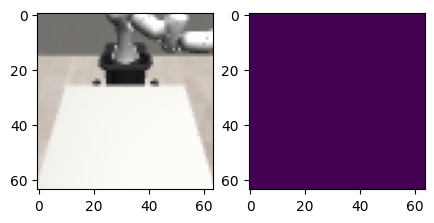

Cube position: [-0.01681683  0.4276419   0.79785526]
Predicted position: [-0.03762039  0.32453358  0.80830973]
Pixels in view: 0


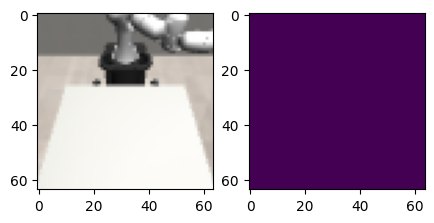

  0%|          | 0/1 [00:20<?, ?it/s]


IsADirectoryError: [Errno 21] Is a directory: './temp'

In [18]:
# get first observation from env (reset), feed it to encoder and get feat, feed features to actor for planning sequence, swap features to test out different objects
import utils
%matplotlib inline
from IPython import display
import imageio

newpath = r'./temp' 
if not os.path.exists(newpath):
    os.makedirs(newpath)

render_size = 64
camera = "agentview"

eval_mode = True

agent_state = None
meta = agent.init_meta()

dreamer_obs = eval_env.reset()
episodes = 1

step, episode, total_reward = 0, 0, 0

reward_fn = (
    lambda seq: agent.wm.heads["object_decoder"](
        seq["feat"], only_mlp=True
    )["objects_pos"][0]
    .mean[:, :, 1]
    .unsqueeze(-1)
) 
        
for ep in tqdm(range(episodes)):
    agent_state = None
    dreamer_obs = eval_env.reset()
    
    with torch.no_grad(), utils.eval_mode(agent):
        while not bool(dreamer_obs['is_last']):
            f, axs = plt.subplots(1, 2, figsize=(5, 5))
            action, agent_state = agent.act(
                                    dreamer_obs,
                                    meta,
                                    step,
                                    eval_mode=False,
                                    state=agent_state,
                                )
        
            dreamer_obs = eval_env.step(action)
        
            seg_pixels = np.argwhere(dreamer_obs["segmentation"][0])
            if len(seg_pixels) > 0:
                centroid = np.mean(seg_pixels, axis=0).astype(int)
                dreamer_obs["rgb"][:, centroid[0], centroid[1]] = [0,255,0]

            axs[0].imshow(dreamer_obs["rgb"].transpose(1,2,0))    
            axs[1].imshow(dreamer_obs["segmentation"][0])
            
            pos = dreamer_obs["objects_pos"]
            print(f"Cube position: {pos[0]}")
            # axs[1].set_title(f"{pos[0]}")
            
            feat = agent.wm.rssm.get_feat(agent_state[0]).unsqueeze(0)
            # print(
            predicted_pos = agent.wm.heads["object_decoder"](
            feat, only_mlp=True)["objects_pos"][0].mean
            
            print(f"Predicted position: {predicted_pos[0, 0].cpu().numpy()}")
            print(f"Pixels in view: { len(seg_pixels)}")
            
            plt.savefig(f'./temp/img_{step}.png', transparent = False, facecolor="white", bbox_inches='tight')
            plt.show()
        
            step += 1
    
    episode += 1
    
    frames = []
    
    for t in range(step):
        image = imageio.v2.imread(f'./temp/img_{t}.png')
        frames.append(image)
        
    imageio.mimsave('./out.gif', # output gif
                frames,          # array of input frames
                fps = 20)  
